In [1]:
import pandas as pd
import numpy as np

In [47]:
df = pd.read_csv("The_Cancer_data_1500_V2.csv")

In [48]:
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [49]:
df.isna().sum()

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

## Here target class is Imbalanced

Diagnosis
0    62.866667
1    37.133333
Name: proportion, dtype: float64


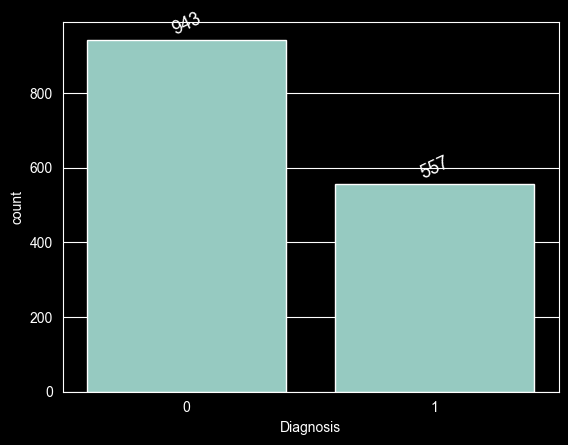

In [51]:
print(df['Diagnosis'].value_counts(normalize=True) * 100)

sns.countplot(df, x="Diagnosis")

# plt.grid(linestyle='--', color='pink')

ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 2,  # a little higher
                int(height), ha='center', va='bottom',
                fontsize=13, rotation=25)  # rotate tex

plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [39]:
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# from xgboost import XGBRegressor
#
# model = XGBRegressor(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=6,
#     random_state=42
# )

model =  LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [54]:
report = classification_report(y_test, y_pred.round())
print(report)

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       184
           1       0.87      0.75      0.81       116

    accuracy                           0.86       300
   macro avg       0.86      0.84      0.85       300
weighted avg       0.86      0.86      0.86       300



In [55]:
score = accuracy_score(y_test, y_pred.round())
print(score)

0.86


# Techniques to handle Imbalance

## Random Undersampling
- Remove samples from the majority class.

In [57]:
from imblearn.under_sampling import RandomUnderSampler

ImportError: sklearn._cyutility does not export expected C function slice_memviewslice